# 5. Dataset Readiness Demonstration

**Objective:** Demonstrate that the dataset supports ML (regression: predict price; or classification: predict price_category).

**Steps:** Train/test 80/20, baseline models (Linear Regression, RandomForest), encoding, evaluation (RMSE, MAE, R²), predicted vs actual, feature importance. Save model.

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib

ROOT = Path.cwd() if (Path.cwd() / "data").exists() else Path.cwd().parent
DATA_LABELED = ROOT / "data" / "processed" / "zoopla_labeled.csv"
MODEL_DIR = ROOT / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR = ROOT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(DATA_LABELED)
df["price"] = pd.to_numeric(df["price"], errors="coerce")
df = df.dropna(subset=["price"])
print("Rows for modelling:", len(df))

Rows for modelling: 14125


In [2]:
# Features: numeric + one-hot for property_type and city
num_cols = ["bedrooms", "bathrooms", "area_sqft", "epc_score", "price_per_sqft", "total_rooms", "has_garden", "has_parking", "has_balcony", "is_renovated", "epc_missing_flag"]
num_cols = [c for c in num_cols if c in df.columns]
cat_cols = [c for c in ["property_type", "city"] if c in df.columns]
X_num = df[num_cols].fillna(0)
X_cat = df[cat_cols].fillna("Unknown")
enc = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
X_cat_enc = enc.fit_transform(X_cat)
X = np.hstack([X_num.values, X_cat_enc])
y = df["price"].values
feature_names = num_cols + enc.get_feature_names_out(cat_cols).tolist()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Train size:", len(y_train), "Test size:", len(y_test))

Train size: 11300 Test size: 2825


In [3]:
# Linear Regression
lr = LinearRegression().fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
print("Linear Regression:")
print("  RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))
print("  MAE:", mean_absolute_error(y_test, y_pred_lr))
print("  R²:", r2_score(y_test, y_pred_lr))
# Random Forest
rf = RandomForestRegressor(n_estimators=100, max_depth=12, random_state=42).fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print("\nRandom Forest:")
print("  RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))
print("  MAE:", mean_absolute_error(y_test, y_pred_rf))
print("  R²:", r2_score(y_test, y_pred_rf))
joblib.dump(rf, MODEL_DIR / "price_rf.pkl")
print("\nSaved model:", MODEL_DIR / "price_rf.pkl")

Linear Regression:
  RMSE: 144566.80767871434
  MAE: 88466.74520468328
  R²: 0.6297360507682643

Random Forest:
  RMSE: 104211.25904919567
  MAE: 60863.08921345086
  R²: 0.8076006799860721

Saved model: /Users/hoamai/Personal/bradford/AI_AND_DATASCIENCE/final_v1/models/price_rf.pkl


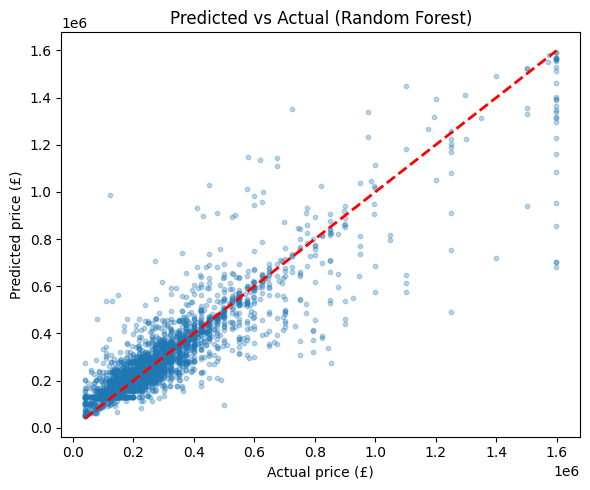

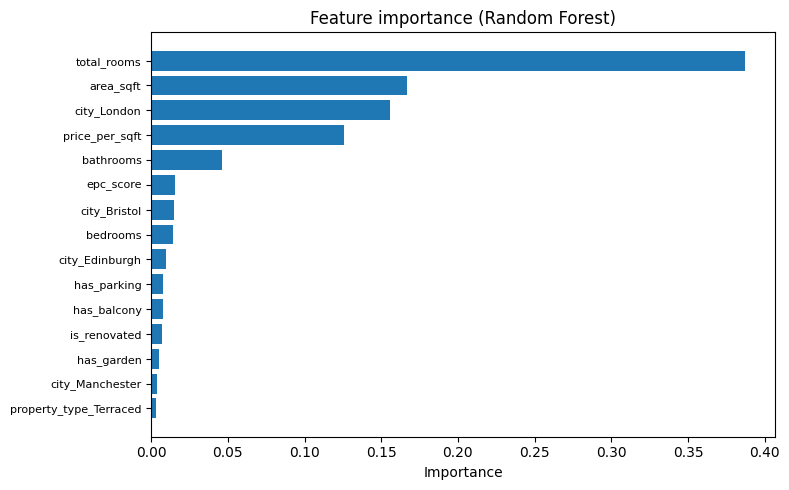

In [4]:
import matplotlib.pyplot as plt

# Predicted vs actual (RF)
plt.figure(figsize=(6, 5))
plt.scatter(y_test, y_pred_rf, alpha=0.3, s=10)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", lw=2)
plt.xlabel("Actual price (£)")
plt.ylabel("Predicted price (£)")
plt.title("Predicted vs Actual (Random Forest)")
plt.tight_layout()
plt.savefig(FIG_DIR / "predicted_vs_actual.png", dpi=150, bbox_inches="tight")
plt.show()
# Feature importance (RF) - use numeric + first few categorical
imp = rf.feature_importances_
idx = np.argsort(imp)[-15:]
plt.figure(figsize=(8, 5))
plt.barh(range(len(idx)), imp[idx])
plt.yticks(range(len(idx)), [feature_names[i] for i in idx], fontsize=8)
plt.xlabel("Importance")
plt.title("Feature importance (Random Forest)")
plt.tight_layout()
plt.savefig(FIG_DIR / "feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

## Interpretation

- **Strong predictors** typically include `area_sqft`, `price_per_sqft`, `bedrooms`, and `city` (location). EPC and text flags (garden, parking) add signal.
- **R²** indicates how much variance in price is explained; RF usually outperforms linear regression when relationships are non-linear (e.g. location, property type).
- **Limitations:** Geographic and property-type imbalance can bias the model; use stratification or city-specific models if deploying per region.